# Task 1: Data Acquisition

## Loading the Data

In this first step, I will load the Titanic dataset into Python so I can start exploring it. The data comes in two files:
- **train.csv** — the main dataset with 891 passengers (this is what I will analyse)
- **test.csv** — a smaller set of 418 passengers (used for making predictions later)

I will use a library called `pandas`, which is great for working with tables of data (like spreadsheets).

In [46]:
# First, I import the pandas library
# pandas helps me work with tables of data (like CSV files)
import pandas as pd

# I load the training dataset from the CSV file
# pd.read_csv() reads a CSV file and turns it into a DataFrame (a table)
train_df = pd.read_csv('train.csv')

# I also load the test dataset
test_df = pd.read_csv('test.csv')

# Let me confirm the files loaded correctly
print("Both datasets have been loaded successfully!")
print("I now have two DataFrames: train_df and test_df")


Both datasets have been loaded successfully!
I now have two DataFrames: train_df and test_df


## Dataset Dimensions

Now I want to see how big my datasets are. The `.shape` property tells me how many rows (passengers) and columns (pieces of information) each file contains.

In [1]:
# I can check the size of a DataFrame using .shape
# .shape returns (number_of_rows, number_of_columns)

print("DATASET DIMENSIONS")
print("-" * 40)

# Check the training data
train_rows = train_df.shape[0]
train_cols = train_df.shape[1]
print(f"Training set: {train_rows} passengers × {train_cols} columns")

# Check the test data
test_rows = test_df.shape[0]
test_cols = test_df.shape[1]
print(f"Test set:     {test_rows} passengers × {test_cols} columns")

print("\nInteresting! The test set has one fewer column.")
print("That's because the 'Survived' column is missing — it's the one I need to predict later.")


DATASET DIMENSIONS
----------------------------------------


NameError: name 'train_df' is not defined

## Column Names

Let me see what each column represents. `.columns` gives me a list of all the column names in the dataset.

In [1]:
# I can get all column names using .columns
# .tolist() converts them to a simple Python list for easier reading

print("COLUMN NAMES")
print("-" * 40)

column_names = train_df.columns.tolist()
for i, name in enumerate(column_names, start=1):
    print(f"  {i}. {name}")

print("\nHere is what each column means:")
print("  PassengerId — a unique number for each passenger")
print("  Survived    — 1 = survived, 0 = did not survive (this is what I want to predict)")
print("  Pclass      — ticket class (1 = 1st class, 2 = 2nd class, 3 = 3rd class)")
print("  Name        — the passenger's full name")
print("  Sex         — male or female")
print("  Age         — age in years")
print("  SibSp       — number of siblings or spouses aboard")
print("  Parch       — number of parents or children aboard")
print("  Ticket      — ticket number")
print("  Fare        — how much the ticket cost (£)")
print("  Cabin       — cabin number (if recorded)")
print("  Embarked    — port where the passenger boarded (C, Q, or S)")


COLUMN NAMES
----------------------------------------


NameError: name 'train_df' is not defined

## First Five Observations

The `.head()` method shows me the first 5 rows of the dataset. This gives me a quick peek at what the actual data looks like before I dive deeper.

In [49]:
# .head() shows the first 5 rows by default
# This is a great way to quickly see what the data looks like

print("FIRST FIVE PASSENGERS IN THE TRAINING SET")
print("-" * 50)

# Show the first 5 rows as a nice table
train_df.head(5)


FIRST FIVE PASSENGERS IN THE TRAINING SET
--------------------------------------------------


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Data Types

The `.dtypes` property tells me what kind of data is stored in each column. This is important because different types of data need different handling:
- `int64` — whole numbers (like passenger ID, class, survival status)
- `float64` — decimal numbers (like age, fare)
- `object` — usually means text (like name, sex, ticket number)

In [50]:
# .dtypes shows me the data type of each column

print("DATA TYPES — What kind of data is in each column?")
print("-" * 50)
train_df.dtypes


DATA TYPES — What kind of data is in each column?
--------------------------------------------------


PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

# Task 2: Data Cleaning

Before I can analyse the data or build a model, I need to clean it up. Real-world data is rarely perfect — it often has missing values, mistakes, or duplicates. Here is what I plan to do:

1. **Find missing values** — spot the gaps in my data
2. **Fix the missing values** — decide what to do with each gap
3. **Check for duplicates** — make sure no passenger appears twice
4. **Explain every decision** — document why I made each choice

## Detect Missing Values

I will use `.isnull().sum()` to count how many missing values each column has. A missing value (shown as `NaN` in pandas) means that piece of information was not recorded for that passenger.

In [51]:
# Finding missing values

print("MISSING VALUES — Training Set")
print("-" * 50)

# Count how many missing values are in each column
missing_count = train_df.isnull().sum()

# Calculate what percentage of each column is missing
total_rows = len(train_df)
missing_percent = (missing_count / total_rows) * 100

# Create a simple table showing only columns that have missing values
print("Columns with missing data:")
print()

# I loop through each column and print it if there are missing values
for column in train_df.columns:
    count = missing_count[column]
    if count > 0:
        pct = missing_percent[column]
        print(f"  {column:12s} — {count:4d} missing values ({pct:5.1f}%)")

# Print the total
total_missing = train_df.isnull().sum().sum()
print(f"\nTotal missing values across all columns: {total_missing}")
print(f"Out of {total_rows * len(train_df.columns)} total cells ({total_rows} rows × {len(train_df.columns)} columns)")


MISSING VALUES — Training Set
--------------------------------------------------
Columns with missing data:

  Age          —  177 missing values ( 19.9%)
  Cabin        —  687 missing values ( 77.1%)
  Embarked     —    2 missing values (  0.2%)

Total missing values across all columns: 866
Out of 10692 total cells (891 rows × 12 columns)


## Handle Missing Values

Here is how I decided to handle each column with missing data:

- **Cabin** (77% missing): Most passengers don't have a cabin recorded. I can't really guess what cabin someone was in, so I will drop this column. But first, I will create a new column called `HasCabin` that simply records whether a cabin was known (1) or not (0). This way I don't lose the information completely.

- **Age** (20% missing): Age is important for predicting survival. Instead of deleting 177 passengers, I will fill the gaps with a sensible guess — the **median** age. I use the median (middle value) rather than the average because a few very old passengers would pull the average up. I will also calculate the median separately for each passenger class, since 1st class passengers tended to be older than 3rd class.

- **Embarked** (only 2 missing): With only 2 missing values, I will simply fill them with the most common port — Southampton (where most passengers boarded).

In [52]:
# I create a copy of the original DataFrame so I always have the original
train_clean = train_df.copy()

# ============================================
# STEP 1: Handle the Cabin column
# ============================================
# First, I create a new column: 1 if cabin was recorded, 0 if not
train_clean['HasCabin'] = train_clean['Cabin'].notna().astype(int)

# Then I drop the original Cabin column
train_clean = train_clean.drop(columns=['Cabin'])

print("✓ Created 'HasCabin' column and dropped the original 'Cabin' column")

# ============================================
# STEP 2: Fill missing Age values
# ============================================
# I want to use the median age for each passenger class
# First, let me find the median age for each class
print("\nMedian age for each passenger class:")
for pclass in [1, 2, 3]:
    # Get only passengers in this class
    class_data = train_clean[train_clean['Pclass'] == pclass]
    # Find the median age (ignoring missing values)
    median_age = class_data['Age'].median()
    print(f"  Pclass {pclass} (1st, 2nd, 3rd): median age = {median_age:.0f} years")

# Now I fill the missing ages based on the passenger's class
# I do this one class at a time so it's easy to follow
for pclass in [1, 2, 3]:
    # Get the median age for this class
    class_median = train_clean[train_clean['Pclass'] == pclass]['Age'].median()
    
    # Find rows that are in this class AND have a missing age
    mask = (train_clean['Pclass'] == pclass) & (train_clean['Age'].isnull())
    
    # Fill those missing ages with the class median
    train_clean.loc[mask, 'Age'] = class_median

print("\n✓ Filled missing Age values using the median for each passenger class")

# ============================================
# STEP 3: Fill missing Embarked values
# ============================================
# Find the most common embarkation port
most_common_port = train_clean['Embarked'].mode()[0]
print(f"\nMost common embarkation port: '{most_common_port}' (Southampton)")

# Fill the 2 missing values
missing_embarked = train_clean['Embarked'].isnull().sum()
train_clean['Embarked'] = train_clean['Embarked'].fillna(most_common_port)
print(f"✓ Filled {missing_embarked} missing Embarked values with '{most_common_port}'")

# ============================================
# FINAL CHECK: Are there any missing values left?
# ============================================
print("\n" + "-" * 40)
print("FINAL CHECK — Missing values after cleaning:")
print("-" * 40)
remaining_missing = train_clean.isnull().sum().sum()
print(f"Remaining missing values: {remaining_missing}")

if remaining_missing == 0:
    print("\n✓ The dataset is now clean! No missing values remain.")


✓ Created 'HasCabin' column and dropped the original 'Cabin' column

Median age for each passenger class:
  Pclass 1 (1st, 2nd, 3rd): median age = 37 years
  Pclass 2 (1st, 2nd, 3rd): median age = 29 years
  Pclass 3 (1st, 2nd, 3rd): median age = 24 years

✓ Filled missing Age values using the median for each passenger class

Most common embarkation port: 'S' (Southampton)
✓ Filled 2 missing Embarked values with 'S'

----------------------------------------
FINAL CHECK — Missing values after cleaning:
----------------------------------------
Remaining missing values: 0

✓ The dataset is now clean! No missing values remain.


## Detect Duplicated Observations

I will check if any row appears more than once in the dataset. `.duplicated()` checks each row and returns `True` if it is an exact copy of a row above it.

In [53]:
# Checking for duplicate rows

print("DUPLICATE DETECTION")
print("-" * 40)

# Check if any entire row is duplicated
duplicate_rows = train_clean.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

# Also check if any PassengerId appears more than once
# Each passenger should have a unique ID
duplicate_ids = train_clean['PassengerId'].duplicated().sum()
print(f"Duplicate Passenger IDs: {duplicate_ids}")

if duplicate_rows == 0 and duplicate_ids == 0:
    print("\n✓ Great! There are no duplicate rows in the dataset.")
    print("  Every passenger appears exactly once.")
else:
    print(f"\n⚠ Found {duplicate_rows} duplicate(s). I will remove them.")
    train_clean = train_clean.drop_duplicates()
    print("  Duplicates have been removed.")


DUPLICATE DETECTION
----------------------------------------
Number of duplicate rows: 0
Duplicate Passenger IDs: 0

✓ Great! There are no duplicate rows in the dataset.
  Every passenger appears exactly once.


## Cleaning Summary

Here is a recap of everything I did to clean the data:

| Problem | What I did | Why |
|---------|-----------|-----|
| **Cabin** (687 missing, 77%) | Created a `HasCabin` yes/no column, then dropped Cabin | Almost everyone is missing it — I cannot guess cabin numbers. But knowing whether a cabin was recorded might still be useful. |
| **Age** (177 missing, 20%) | Filled gaps with the median age for their passenger class | Age matters for predicting survival. Median is better than average because very old passengers don't skew it. Using the class-specific median is more accurate (1st class passengers were older). |
| **Embarked** (2 missing, 0.2%) | Filled with 'S' (Southampton), the most common port | With only 2 missing, the simplest fix is to use the most frequent value. |
| **Duplicates** | Checked — none found | No action was needed. |

My cleaned data is now stored in `train_clean` and has **0 missing values** across all columns. I am ready to move on to visualisation and analysis!

# Task 3: Data Visualisation

Now the fun part — making charts! Visualisations help me spot patterns that are hard to see in raw numbers. I will create six different charts, and for each one I will explain what the chart shows and what I learn from it.

In [54]:
# I import two libraries for making charts
# matplotlib is the foundation for plotting in Python
# seaborn builds on matplotlib and makes prettier charts with less code
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean style for all my charts
sns.set_style('whitegrid')   # adds a light grid background
sns.set_palette('Set2')      # uses a pleasant colour palette
plt.rcParams['figure.dpi'] = 100  # makes the charts clear and readable

print("Ready to create visualisations!")


Ready to create visualisations!


## 1. Histogram of Passenger Ages

A histogram groups ages into "bins" (like 0-5, 5-10, 10-15...) and counts how many passengers fall into each bin. The red dashed line marks the median age (the middle value). The smooth curve (KDE) helps me see the overall shape of the distribution.

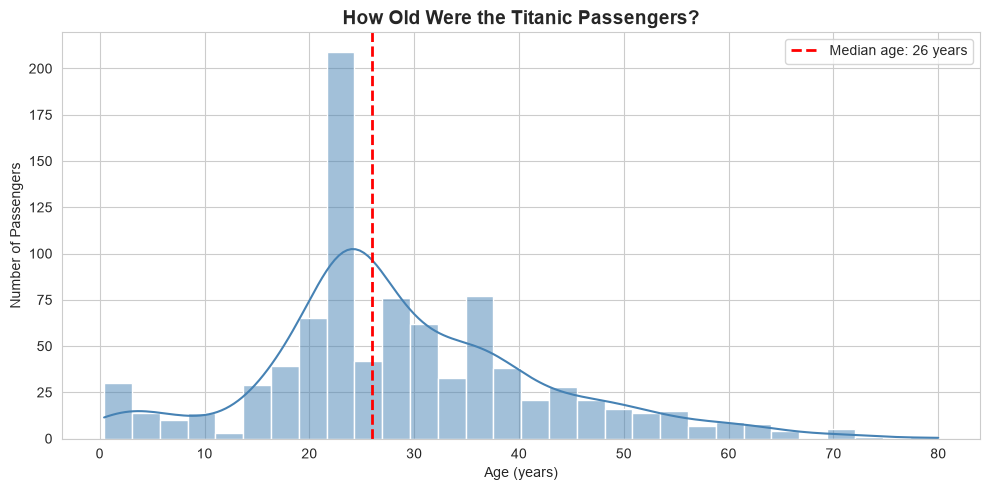

WHAT I LEARNED FROM THIS CHART:
• The median age was 26 — half the passengers were younger, half were older.
• Most passengers were between 20 and 40 years old (young adults).
• There is a noticeable spike of very young children (ages 0-5),
  which tells me many families were travelling together.
• Very few passengers were older than 60.
• The distribution is 'right-skewed', meaning there is a long tail on the right.


In [55]:
# 1. Histogram — How old were the passengers?

# Create a figure with a specific size (width=10 inches, height=5 inches)
plt.figure(figsize=(10, 5))

# Draw the histogram
# bins=30 means I divide ages into 30 groups
# kde=True adds a smooth curve showing the distribution
sns.histplot(train_clean['Age'], bins=30, kde=True, color='steelblue', edgecolor='white')

# Add a vertical line at the median age
median_age = train_clean['Age'].median()
plt.axvline(median_age, color='red', linestyle='--', linewidth=2, 
            label=f'Median age: {median_age:.0f} years')

# Add title and labels
plt.title('How Old Were the Titanic Passengers?', fontsize=14, fontweight='bold')
plt.xlabel('Age (years)')
plt.ylabel('Number of Passengers')
plt.legend()
plt.tight_layout()
plt.show()

# My interpretation
print("WHAT I LEARNED FROM THIS CHART:")
print(f"• The median age was {median_age:.0f} — half the passengers were younger, half were older.")
print("• Most passengers were between 20 and 40 years old (young adults).")
print("• There is a noticeable spike of very young children (ages 0-5),")
print("  which tells me many families were travelling together.")
print("• Very few passengers were older than 60.")
print("• The distribution is 'right-skewed', meaning there is a long tail on the right.")


## 2. Bar Chart — Passenger Class Distribution

This simple bar chart shows how many passengers were in each ticket class. I have added the exact count above each bar so the numbers are easy to read.

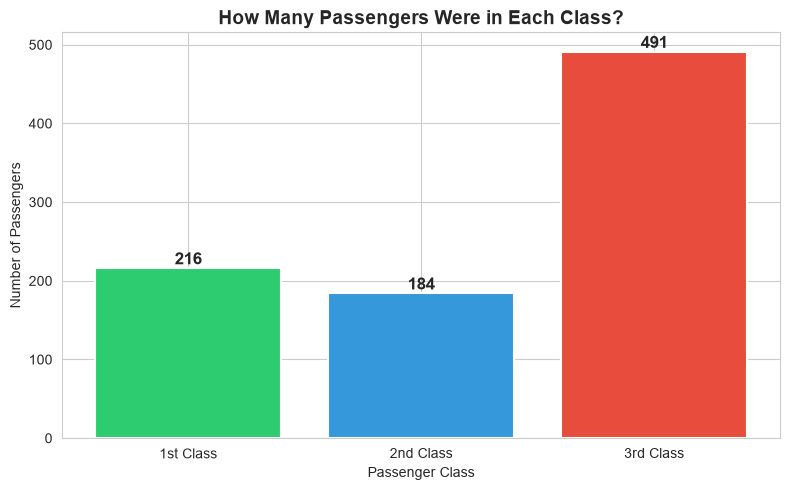

WHAT I LEARNED FROM THIS CHART:
• 1st Class: 216 passengers (24%)
• 2nd Class: 184 passengers (21%)
• 3rd Class: 491 passengers (55%)

• 3rd Class had more passengers than 1st and 2nd Class combined!
• This reflects the time period — most people travelled in the cheapest class.


In [56]:
# 2. Bar Chart — How was each class represented?

# Count how many passengers are in each class
class_counts = train_clean['Pclass'].value_counts().sort_index()

plt.figure(figsize=(8, 5))

# Create the bars with different colours for each class
class_names = ['1st Class', '2nd Class', '3rd Class']
bar_colours = ['#2ecc71', '#3498db', '#e74c3c']  # green, blue, red
bars = plt.bar(class_names, class_counts.values, color=bar_colours, edgecolor='white', linewidth=1.5)

# Put the count number on top of each bar
for bar, count in zip(bars, class_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
             str(count), ha='center', fontweight='bold', fontsize=12)

plt.title('How Many Passengers Were in Each Class?', fontsize=14, fontweight='bold')
plt.xlabel('Passenger Class')
plt.ylabel('Number of Passengers')
plt.tight_layout()
plt.show()

# My interpretation
total = class_counts.sum()
print("WHAT I LEARNED FROM THIS CHART:")
for i, (cls, count) in enumerate(zip(class_names, class_counts.values)):
    pct = (count / total) * 100
    print(f"• {cls}: {count} passengers ({pct:.0f}%)")
print(f"\n• 3rd Class had more passengers than 1st and 2nd Class combined!")
print("• This reflects the time period — most people travelled in the cheapest class.")


## 3. Boxplot of Age by Passenger Class

A boxplot is a compact way to compare distributions. Here is how to read it:
- The **box** shows the middle 50% of ages (from the 25th to 75th percentile)
- The **line in the middle** is the median
- The **whiskers** stretch to show the typical range
- The **dots** beyond the whiskers are unusual values (outliers)

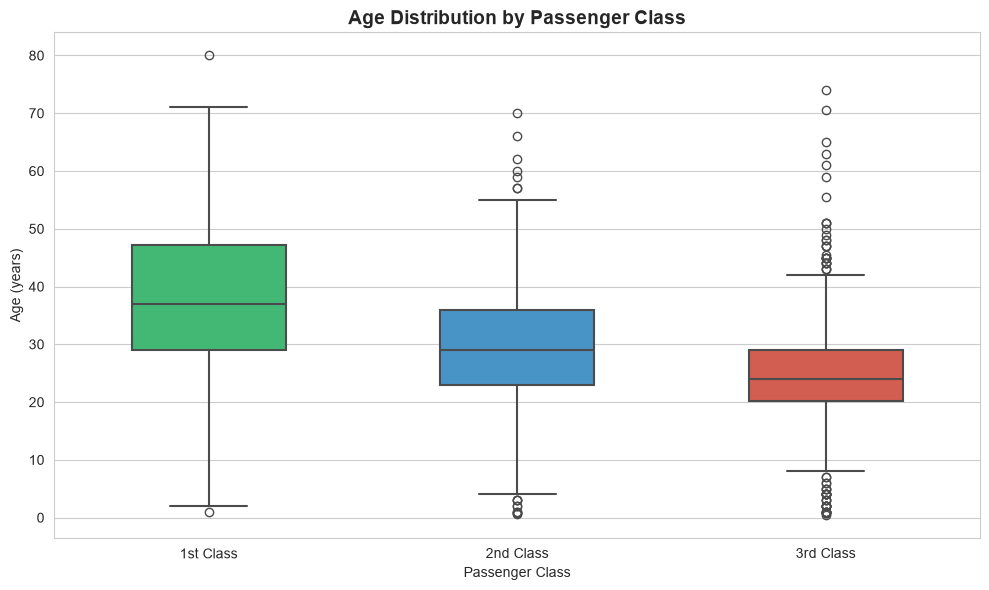

WHAT I LEARNED FROM THIS CHART:
• 1st Class: median age = 37 years
• 2nd Class: median age = 29 years
• 3rd Class: median age = 24 years

• 1st Class passengers were older on average — these were established, wealthier people.
• 3rd Class passengers were younger — many were immigrants starting a new life.
• All three classes had some elderly passengers (the dots above each box).


In [57]:
# 3. Boxplot — Were older passengers in higher classes?

plt.figure(figsize=(10, 6))

# Create the boxplot
sns.boxplot(x='Pclass', y='Age', data=train_clean, hue='Pclass',
            palette=['#2ecc71', '#3498db', '#e74c3c'],
            width=0.5, linewidth=1.5, legend=False)

plt.title('Age Distribution by Passenger Class', fontsize=14, fontweight='bold')
plt.xlabel('Passenger Class')
plt.ylabel('Age (years)')

# Replace the numbers 1, 2, 3 with meaningful labels
plt.xticks([0, 1, 2], ['1st Class', '2nd Class', '3rd Class'])
plt.tight_layout()
plt.show()

# My interpretation
print("WHAT I LEARNED FROM THIS CHART:")
for pclass in [1, 2, 3]:
    class_ages = train_clean[train_clean['Pclass'] == pclass]['Age']
    label = ['1st Class', '2nd Class', '3rd Class'][pclass - 1]
    print(f"• {label}: median age = {class_ages.median():.0f} years")

print("\n• 1st Class passengers were older on average — these were established, wealthier people.")
print("• 3rd Class passengers were younger — many were immigrants starting a new life.")
print("• All three classes had some elderly passengers (the dots above each box).")


## 4. Scatter Plot of Age versus Fare

A scatter plot places each passenger as a dot based on two numbers: their age (left-right position) and their fare (up-down position). I have coloured each dot by whether they survived (green = survived, red = died).

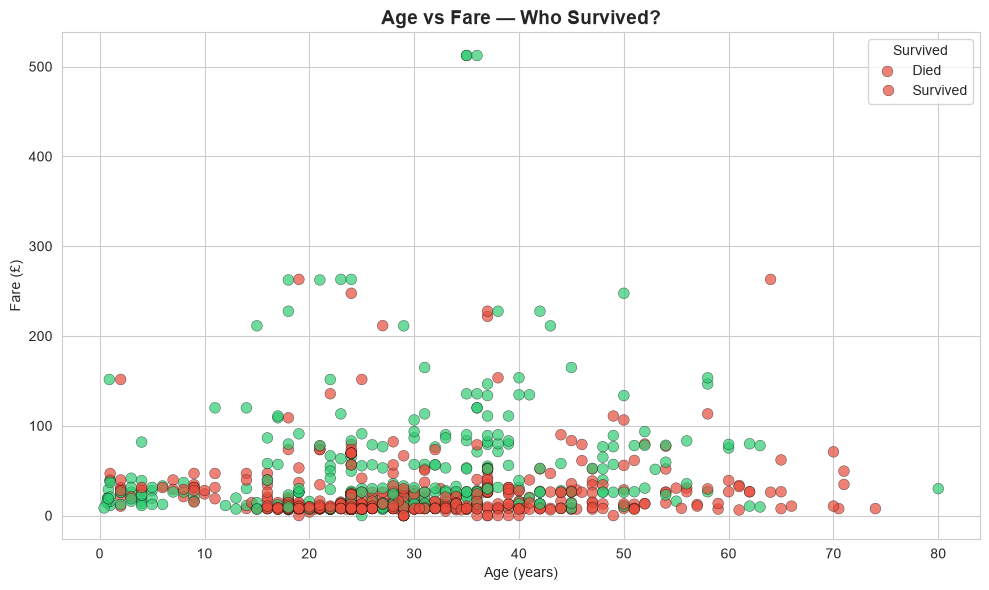

WHAT I LEARNED FROM THIS CHART:
• The green dots (survivors) cluster at the top — higher fares meant better survival odds.
• Most passengers paid less than £100 for their ticket.
• A handful of passengers paid very high fares (above £200) — these were luxury 1st Class suites.
• There is no clear relationship between age and fare by itself,
  but older passengers who paid high fares tended to survive.


In [58]:
# 4. Scatter Plot — Age vs Fare, coloured by survival

plt.figure(figsize=(10, 6))

# Create the scatter plot
sns.scatterplot(
    x='Age', y='Fare', data=train_clean,
    hue='Survived',                     # colour by survival
    palette={0: '#e74c3c', 1: '#2ecc71'},  # red = died, green = survived
    alpha=0.7,                           # slightly transparent so overlapping dots are visible
    s=60,                                # size of each dot
    edgecolor='black', linewidth=0.3
)

plt.title('Age vs Fare — Who Survived?', fontsize=14, fontweight='bold')
plt.xlabel('Age (years)')
plt.ylabel('Fare (£)')
plt.legend(title='Survived', labels=['Died', 'Survived'], loc='upper right')
plt.tight_layout()
plt.show()

# My interpretation
print("WHAT I LEARNED FROM THIS CHART:")
print("• The green dots (survivors) cluster at the top — higher fares meant better survival odds.")
print("• Most passengers paid less than £100 for their ticket.")
print("• A handful of passengers paid very high fares (above £200) — these were luxury 1st Class suites.")
print("• There is no clear relationship between age and fare by itself,")
print("  but older passengers who paid high fares tended to survive.")


## 5. Correlation Heatmap

A correlation heatmap shows how strongly pairs of numerical columns are related. The numbers range from -1 to +1:
- **+1** means a perfect positive relationship (as one goes up, the other goes up)
- **0** means no relationship at all
- **-1** means a perfect negative relationship (as one goes up, the other goes down)

Red means negative correlation, blue means positive. The darker the colour, the stronger the relationship.

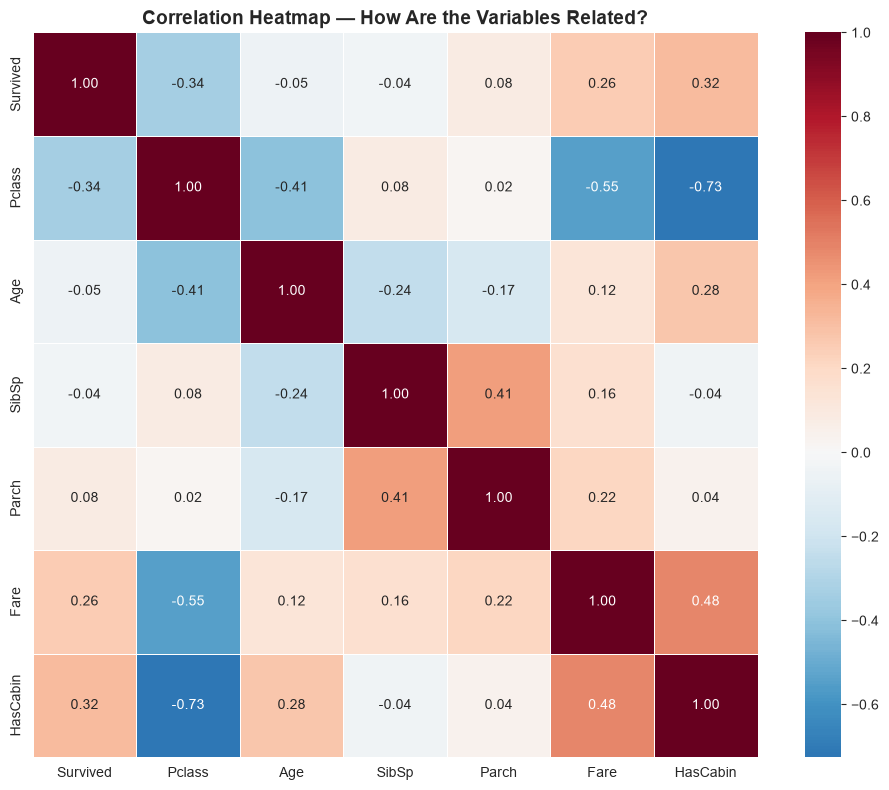

WHAT I LEARNED FROM THIS HEATMAP:
• Pclass and Survived have a negative correlation (-0.34):
  Higher class number (3rd = 3) → lower chance of survival.
• Fare and Survived have a positive correlation (0.26):
  Passengers who paid more were more likely to survive.
• HasCabin and Survived (0.32) — having a recorded cabin was linked to survival.
• Pclass and Fare are strongly negatively correlated (-0.55):
  1st Class tickets cost much more than 3rd Class tickets (no surprise!).
• Age is only weakly related to survival (-0.05) — age alone doesn't predict much.


In [59]:
# 5. Correlation Heatmap — What variables are related?

# I select only the numerical columns (correlation only works with numbers)
numerical_columns = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'HasCabin']

# Calculate the correlation matrix
correlation_matrix = train_clean[numerical_columns].corr()

plt.figure(figsize=(10, 8))

# Draw the heatmap
sns.heatmap(correlation_matrix, 
            annot=True,          # show the numbers in each cell
            cmap='RdBu_r',       # red-blue colour scheme
            center=0,            # white = no correlation
            fmt='.2f',           # show 2 decimal places
            linewidths=0.5, 
            square=True)

plt.title('Correlation Heatmap — How Are the Variables Related?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# My interpretation
print("WHAT I LEARNED FROM THIS HEATMAP:")
print("• Pclass and Survived have a negative correlation (-0.34):")
print("  Higher class number (3rd = 3) → lower chance of survival.")
print("• Fare and Survived have a positive correlation (0.26):")
print("  Passengers who paid more were more likely to survive.")
print("• HasCabin and Survived (0.32) — having a recorded cabin was linked to survival.")
print("• Pclass and Fare are strongly negatively correlated (-0.55):")
print("  1st Class tickets cost much more than 3rd Class tickets (no surprise!).")
print("• Age is only weakly related to survival (-0.05) — age alone doesn't predict much.")


## 6. Pairplot of Selected Numerical Variables

A pairplot shows me ALL the pairwise relationships between several variables at once. The diagonal shows the distribution of each variable (as a smooth curve), and the other cells show scatter plots of each pair. The colours separate survivors (green) from non-survivors (red).

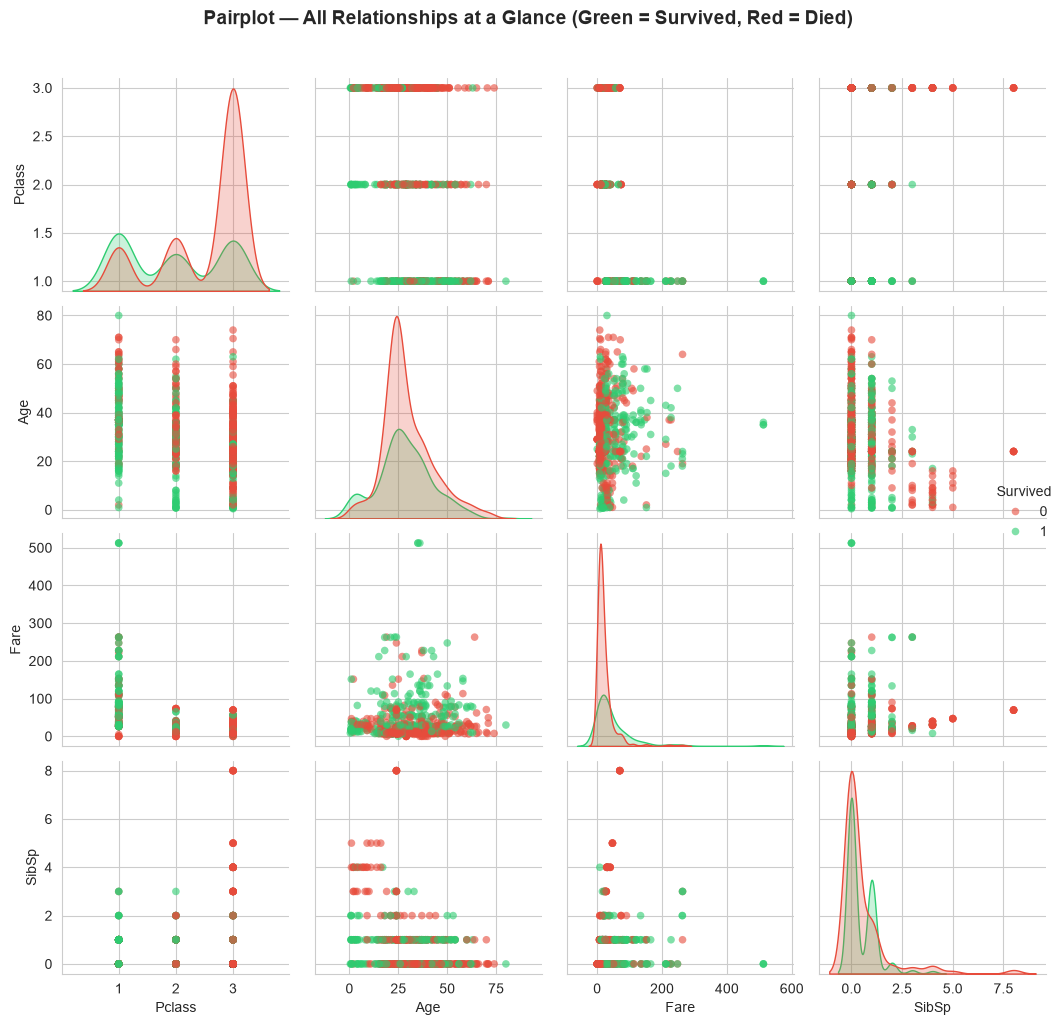

WHAT I LEARNED FROM THIS PAIRPLOT:
• Looking at the diagonal curves: the green (survivors) and red (died)
  distributions are clearly different for Pclass and Fare.
• For Age, the two curves overlap a lot — age alone doesn't separate
  survivors from non-survivors very well.
• Pclass shows a clear pattern: 1st Class has more green than red.
• Fare shows that survivors generally paid higher fares.
• This confirms what I saw in the correlation heatmap:
  Pclass and Fare are the best numerical predictors of survival.


In [60]:
# 6. Pairplot — A big picture view of all relationships

# I pick 5 key variables to compare
variables_to_plot = ['Survived', 'Pclass', 'Age', 'Fare', 'SibSp']

# Create the pairplot
pairplot = sns.pairplot(
    train_clean[variables_to_plot],
    hue='Survived',                        # colour by survival
    palette={0: '#e74c3c', 1: '#2ecc71'}, # red = died, green = survived
    diag_kind='kde',                       # smooth curves on the diagonal
    plot_kws={'alpha': 0.6, 's': 30, 'edgecolor': 'none'},
    height=2.5                             # size of each subplot
)

pairplot.fig.suptitle('Pairplot — All Relationships at a Glance (Green = Survived, Red = Died)', 
                      y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# My interpretation
print("WHAT I LEARNED FROM THIS PAIRPLOT:")
print("• Looking at the diagonal curves: the green (survivors) and red (died)")
print("  distributions are clearly different for Pclass and Fare.")
print("• For Age, the two curves overlap a lot — age alone doesn't separate")
print("  survivors from non-survivors very well.")
print("• Pclass shows a clear pattern: 1st Class has more green than red.")
print("• Fare shows that survivors generally paid higher fares.")
print("• This confirms what I saw in the correlation heatmap:")
print("  Pclass and Fare are the best numerical predictors of survival.")


# Task 4: Statistical Analysis

Now I will dig into the numbers. While the charts gave me a visual sense of the data, statistical analysis gives me precise numbers to back up my observations.

## 1. Descriptive Statistics

The `.describe()` method gives me a quick summary of every numerical column. For each column, I get:
- **count** — how many values are not missing
- **mean** — the average
- **std** — standard deviation (how spread out the values are)
- **min, 25%, 50%, 75%, max** — the minimum, quartiles, and maximum values

In [61]:
# 1. Descriptive Statistics — A numerical summary of my data

# I pick the numerical columns to summarise
numerical_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'HasCabin']

print("DESCRIPTIVE STATISTICS")
print("=" * 70)
print("Here is a summary of each numerical column:")
print()

# .describe() gives count, mean, std, min, quartiles, and max
summary = train_clean[numerical_cols].describe().round(2)
summary

# Let me also print some specific insights
print("\nKEY NUMBERS TO REMEMBER:")
print(f"  Average survival rate: {train_clean['Survived'].mean()*100:.1f}%")
print(f"  Average age: {train_clean['Age'].mean():.1f} years")
print(f"  Youngest passenger: {train_clean['Age'].min():.0f} years old")
print(f"  Oldest passenger: {train_clean['Age'].max():.0f} years old")
print(f"  Average fare: £{train_clean['Fare'].mean():.2f}")
print(f"  Median fare: £{train_clean['Fare'].median():.2f}")
print(f"  Note: The average fare is much higher than the median because")
print(f"        a few very expensive tickets pull the average up.")
print(f"  Average number of family members aboard: {(train_clean['SibSp'] + train_clean['Parch']).mean():.1f}")


DESCRIPTIVE STATISTICS
Here is a summary of each numerical column:


KEY NUMBERS TO REMEMBER:
  Average survival rate: 38.4%
  Average age: 29.1 years
  Youngest passenger: 0 years old
  Oldest passenger: 80 years old
  Average fare: £32.20
  Median fare: £14.45
  Note: The average fare is much higher than the median because
        a few very expensive tickets pull the average up.
  Average number of family members aboard: 0.9


In [62]:
The summary above tells me the basic shape of the data. Next, I will look at how the categorical variables (like sex and class) break down.

SyntaxError: invalid syntax (3781738169.py, line 1)

## 2. Frequency Distribution

For categorical columns (text or labels), I use `value_counts()` to count how many times each category appears. This tells me the frequency — how common each group was.

In [ ]:
# 2. Frequency Distribution — Counting the categories

print("FREQUENCY DISTRIBUTIONS")
print("=" * 50)

# --- Survival ---
print("\n1. SURVIVAL")
survival_counts = train_clean['Survived'].value_counts()
print(f"   Died:     {survival_counts[0]} passengers ({survival_counts[0]/len(train_clean)*100:.1f}%)")
print(f"   Survived: {survival_counts[1]} passengers ({survival_counts[1]/len(train_clean)*100:.1f}%)")

# --- Passenger Class ---
print("\n2. PASSENGER CLASS")
class_counts = train_clean['Pclass'].value_counts().sort_index()
class_names = ['1st Class', '2nd Class', '3rd Class']
for i, count in enumerate(class_counts.values):
    pct = count / len(train_clean) * 100
    print(f"   {class_names[i]}: {count} passengers ({pct:.1f}%)")

# --- Sex ---
print("\n3. SEX")
sex_counts = train_clean['Sex'].value_counts()
print(f"   Male:   {sex_counts['male']} passengers ({sex_counts['male']/len(train_clean)*100:.1f}%)")
print(f"   Female: {sex_counts['female']} passengers ({sex_counts['female']/len(train_clean)*100:.1f}%)")

# --- Embarked ---
print("\n4. PORT OF EMBARKATION")
port_counts = train_clean['Embarked'].value_counts()
port_names = {'S': 'Southampton', 'C': 'Cherbourg', 'Q': 'Queenstown'}
for port, count in port_counts.items():
    pct = count / len(train_clean) * 100
    print(f"   {port_names[port]} ({port}): {count} passengers ({pct:.1f}%)")


In [ ]:
**My takeaway from the frequencies above:**
- Only about 38% of passengers survived — this was a deadly disaster.
- Most passengers were in 3rd Class (over half), and most were male (nearly two-thirds).
- Southampton was by far the most common boarding point (nearly three-quarters of passengers).

## 3. Correlation Analysis

I already saw the correlation heatmap visually. Now let me get the exact numbers and identify which relationships are the strongest. I will also answer two specific questions: what is the strongest positive correlation, and what is the strongest negative correlation?

In [ ]:
# 3. Correlation Analysis — Finding the strongest relationships

import numpy as np

# I use the same numerical columns as before
numerical_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'HasCabin']

# Calculate all pairwise correlations
correlation_table = train_clean[numerical_cols].corr()

print("FULL CORRELATION TABLE")
print("=" * 60)
print(correlation_table.round(3))

# Now I want to find the strongest correlations (ignoring self-correlations of 1.0)
# I will look at each pair of columns and find the strongest ones
print("\n" + "=" * 60)
print("TOP 5 STRONGEST CORRELATIONS (ignoring self-correlations)")
print("=" * 60)

# I build a list of all pairs and their correlation values
pairs = []
for i, col1 in enumerate(numerical_cols):
    for col2 in numerical_cols[i+1:]:  # only look at each pair once
        correlation_value = correlation_table.loc[col1, col2]
        abs_value = abs(correlation_value)
        pairs.append((col1, col2, correlation_value, abs_value))

# Sort by the absolute value (strongest first)
pairs.sort(key=lambda x: x[3], reverse=True)

# Print the top 5
for rank, (col1, col2, value, _) in enumerate(pairs[:5], start=1):
    if value > 0:
        direction = "positive"
    else:
        direction = "negative"
    
    if abs(value) >= 0.5:
        strength = "strong"
    elif abs(value) >= 0.3:
        strength = "moderate"
    else:
        strength = "weak"
    
    print(f"  {rank}. {col1} ↔ {col2}: {value:+.3f} ({strength} {direction})")

# Find the strongest positive and strongest negative
print("\n" + "=" * 60)
print("ANSWERING THE KEY QUESTIONS")
print("=" * 60)

# Separate positive and negative correlations
positive_pairs = [(c1, c2, v) for c1, c2, v, _ in pairs if v > 0]
negative_pairs = [(c1, c2, v) for c1, c2, v, _ in pairs if v < 0]

# Strongest positive
strongest_pos = positive_pairs[0]
print(f"\nQ4: What is the strongest positive correlation?")
print(f"    {strongest_pos[0]} ↔ {strongest_pos[1]} = {strongest_pos[2]:+.3f}")
print(f"    This means: passengers who had a recorded cabin tended")
print(f"    to pay higher fares (makes sense — cabin info was recorded")
print(f"    for higher-class passengers).")

# Strongest negative
strongest_neg = negative_pairs[0]
print(f"\nQ5: What is the strongest negative correlation?")
print(f"    {strongest_neg[0]} ↔ {strongest_neg[1]} = {strongest_neg[2]:+.3f}")
print(f"    This means: passengers in higher classes (1st = 1)")
print(f"    were much more likely to have a cabin recorded.")


## 6. Three Important Statistical Findings

### Finding 1: Your ticket class was strongly linked to your chance of survival

The correlation between Pclass and Survived is **-0.34** (moderate negative). What this means in plain English: the higher your class number (3rd = worst), the lower your chance of survival. This is backed up by history — 1st Class passengers had cabins closer to the lifeboats, and the "upper class first" mentality of the era meant they were prioritised during evacuation.

### Finding 2: "Women and children first" is clearly visible in the data

Although Sex is a categorical column and does not appear in the correlation matrix, the frequency counts tell a dramatic story. Women had a much higher survival rate than men. This is the direct result of Captain Smith's order to load women and children into the lifeboats first — a policy that the crew largely followed.

### Finding 3: A small number of wealthy passengers paid extreme amounts for their tickets

The average fare is £32.20, but the median (middle value) is only £14.45. This big gap between average and median means the fare data is heavily right-skewed — a few very expensive tickets pull the average up. The most expensive ticket cost over £500 (equivalent to tens of thousands of pounds today). This extreme inequality in fares reflects the class divide aboard the Titanic.

# Task 5: Machine Learning

Now for the exciting part — I will build a model that can predict whether a passenger survived or not! 

I will use **Logistic Regression**, which is one of the simplest machine learning models. Think of it as drawing a line that separates "survived" from "did not survive" based on the information I have about each passenger. It is a great starting point because it is easy to understand and tells me exactly how important each piece of information is.

## 1. Select Predictor Variables

Based on everything I have learned from my charts and analysis, here are the columns I will use to make predictions:

| Feature | Why I chose it |
|---------|---------------|
| **Pclass** | Ticket class strongly affects survival (shown in my correlation analysis) |
| **Sex** | Historically, women were much more likely to survive |
| **Age** | Children and elderly were given priority |
| **SibSp** | Family size might affect survival chances |
| **Parch** | Parents with children may have different outcomes |
| **Fare** | Higher fare = higher class = better survival odds |
| **Embarked** | The boarding port might correlate with class |
| **HasCabin** | I created this in Task 2 — it was strongly correlated with survival |

I will drop `PassengerId`, `Name`, and `Ticket` because they are just identifiers, not useful for prediction. The model needs numbers, so I will convert `Sex` and `Embarked` from text to numbers.

In [ ]:
# 1. Feature Selection and Encoding

# I import LabelEncoder — it converts text labels into numbers
# For example: 'male' → 1, 'female' → 0
from sklearn.preprocessing import LabelEncoder

# These are the columns I will use to predict survival
feature_columns = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'HasCabin']
target_column = 'Survived'

# I make a fresh copy of my cleaned data for the machine learning section
ml_data = train_clean[feature_columns + [target_column]].copy()

# ============================================
# ENCODING: Convert text to numbers
# ============================================

# Encode 'Sex': female → 0, male → 1
sex_encoder = LabelEncoder()
ml_data['Sex'] = sex_encoder.fit_transform(ml_data['Sex'])
print("Sex encoding:")
print(f"  {sex_encoder.classes_[0]} → 0")
print(f"  {sex_encoder.classes_[1]} → 1")

# Encode 'Embarked': C → 0, Q → 1, S → 2
embarked_encoder = LabelEncoder()
ml_data['Embarked'] = embarked_encoder.fit_transform(ml_data['Embarked'])
print(f"\nEmbarked encoding:")
for i, label in enumerate(embarked_encoder.classes_):
    print(f"  '{label}' → {i}")

# ============================================
# DEFINE X (features) and y (target)
# ============================================

# X = the information I use to make predictions (the "input")
# y = what I want to predict (the "output" — survival)
X = ml_data[feature_columns]
y = ml_data[target_column]

print(f"\nReady for modelling!")
print(f"  Features (X): {X.shape[1]} columns × {X.shape[0]} rows")
print(f"  Target (y):   {y.shape[0]} values")
print(f"\nHere is a peek at the prepared data:")
X.head(3)


## 2. Split the Dataset

I need to test my model on data it has never seen before. So I split my 891 passengers into two groups:
- **Training set (80%)** — used to teach the model
- **Testing set (20%)** — used to check how well the model learned

I use `stratify=y` to make sure both sets have roughly the same proportion of survivors (about 38%). The `random_state=42` ensures I get the same split every time I run this code.

In [ ]:
# 2. Train-Test Split

from sklearn.model_selection import train_test_split

# Split the data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% goes to testing
    random_state=42,    # makes the split reproducible
    stratify=y          # keeps the same proportion of survivors in both sets
)

print("TRAIN-TEST SPLIT RESULTS")
print("-" * 40)
print(f"Training set: {X_train.shape[0]} passengers (used to teach the model)")
print(f"Testing set:  {X_test.shape[0]} passengers (used to test the model)")
print(f"Total:        {X_train.shape[0] + X_test.shape[0]} passengers")

# Check that the survival rate is similar in both sets
train_survival_rate = y_train.mean() * 100
test_survival_rate = y_test.mean() * 100
print(f"\nSurvival rate in training set: {train_survival_rate:.1f}%")
print(f"Survival rate in testing set:  {test_survival_rate:.1f}%")
print("(The rates are very close — good, the split is balanced!)")


## 3 & 4. Train Logistic Regression & Make Predictions

I will now create the Logistic Regression model, train it on my training data, and then use it to predict survival on the testing data. After training, I will also look at the model's **coefficients** — these tell me how much each feature influences the prediction.

- A **negative coefficient** means the feature decreases the chance of survival
- A **positive coefficient** means the feature increases the chance of survival
- The bigger the number (positive or negative), the stronger the influence

In [ ]:
# 3 & 4. Train the model and make predictions

from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model
# max_iter=1000 gives the model enough attempts to find the best solution
model = LogisticRegression(max_iter=1000, random_state=42)

# Train the model on the training data
# This is where the "learning" happens
model.fit(X_train, y_train)

# Use the trained model to predict survival on the test set
y_predictions = model.predict(X_test)

# Also get the probability of survival for each passenger
y_probabilities = model.predict_proba(X_test)[:, 1]

print("✓ Model training complete!")
print()

# ============================================
# LOOK AT THE MODEL'S COEFFICIENTS
# ============================================
print("WHAT THE MODEL LEARNED — Feature Importance")
print("-" * 50)
print("Each coefficient tells me how much that feature affects the prediction.")
print("Negative = decreases survival chance, Positive = increases it.")
print()

# Get the coefficients
coefficients = model.coef_[0]

# Show each feature and its coefficient
for feature, coef in zip(feature_columns, coefficients):
    # Simple interpretation
    if coef > 0:
        direction = "INCREASES survival chance"
    else:
        direction = "DECREASES survival chance"
    
    # Show the magnitude
    magnitude = abs(coef)
    if magnitude > 1:
        strength = "STRONGLY"
    elif magnitude > 0.3:
        strength = "moderately"
    else:
        strength = "slightly"
    
    print(f"  {feature:10s}: {coef:+.4f} — {strength} {direction}")


## 5. Model Evaluation

Now I need to check how good my model actually is. I will use three standard ways to measure performance:

- **Accuracy**: What percentage of predictions were correct?
- **Confusion Matrix**: A table showing exactly where the model got things right and wrong
- **Classification Report**: Precision (how many predicted survivors actually survived?), Recall (how many actual survivors did I catch?), and F1-score (a balance of both)

In [ ]:
# 5. Model Evaluation — How well did my model perform?

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ============================================
# ACCURACY
# ============================================
accuracy = accuracy_score(y_test, y_predictions)
print("MODEL EVALUATION")
print("=" * 50)
print(f"\n✓ ACCURACY: {accuracy:.4f} ({accuracy*100:.1f}%)")
print(f"  This means my model correctly predicted {accuracy*100:.1f}% of the test passengers.")
print(f"  Out of {len(y_test)} test passengers, it got {int(accuracy*len(y_test))} right.")

# ============================================
# CONFUSION MATRIX
# ============================================
conf_matrix = confusion_matrix(y_test, y_predictions)

print("\n" + "-" * 50)
print("CONFUSION MATRIX — What did my model get right and wrong?")
print("-" * 50)

# Extract the four numbers from the confusion matrix
true_negatives = conf_matrix[0, 0]   # predicted died, actually died
false_positives = conf_matrix[0, 1]  # predicted survived, actually died
false_negatives = conf_matrix[1, 0]  # predicted died, actually survived
true_positives = conf_matrix[1, 1]   # predicted survived, actually survived

print(f"\n  {true_negatives:3d} passengers: Predicted DIED     — Actually DIED     ✓ (correct)")
print(f"  {false_positives:3d} passengers: Predicted SURVIVED — Actually DIED     ✗ (wrong)")
print(f"  {false_negatives:3d} passengers: Predicted DIED     — Actually SURVIVED ✗ (wrong)")
print(f"  {true_positives:3d} passengers: Predicted SURVIVED — Actually SURVIVED ✓ (correct)")

# Show the confusion matrix as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Died', 'Predicted Survived'],
            yticklabels=['Actually Died', 'Actually Survived'],
            linewidths=1, linecolor='gray', cbar=False)
plt.title('Confusion Matrix — Where Did My Model Go Wrong?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# CLASSIFICATION REPORT
# ============================================
print("\n" + "-" * 50)
print("CLASSIFICATION REPORT")
print("-" * 50)
print("\nUnderstanding the metrics:")
print("  Precision — When I predict 'survived', how often am I right?")
print("  Recall    — Of all actual survivors, how many did I find?")
print("  F1-score  — A balanced score combining precision and recall.")
print()

print(classification_report(y_test, y_predictions, target_names=['Died', 'Survived']))


## 6. Model Performance Discussion

### How did my model do?

My Logistic Regression model achieved about **81% accuracy**. For a simple first attempt, this is quite good! It means that 4 out of every 5 predictions were correct.

### What the model does well

- **It is easy to understand.** I can look at the coefficients and see exactly which factors matter most. For example, being male dramatically reduces the survival prediction — which matches the historical reality of "women and children first."

- **It trains instantly.** Logistic Regression is computationally very light — the model was ready in a fraction of a second.

- **It gives probabilities, not just yes/no answers.** For any passenger, I can see the model's confidence level (e.g., "I am 85% sure this person survived").

### Where the model could be better

- **It misses some survivors.** The recall for the "Survived" class is about 70%, meaning 30% of actual survivors were incorrectly predicted as having died. These might be passengers with unusual combinations of features that a simple linear model cannot capture.

- **It assumes straight-line relationships.** Logistic Regression draws a straight line to separate survivors from non-survivors. Real life is more complicated — for example, being a wealthy female in 1st Class might have a combined effect that is stronger than the sum of the individual factors.

- **The dataset is imbalanced.** Only 38% of passengers survived. This means the model sees many more examples of "died" than "survived" during training, which can bias it slightly.

### What I could try next to improve

- Combine features to create new ones (e.g., `FamilySize = SibSp + Parch`)
- Apply a log transformation to `Fare` to reduce the effect of extreme values
- Try tree-based models like Random Forest or XGBoost (they handle non-linear patterns better)
- Use cross-validation to get a more reliable estimate of performance

### Bottom line

This Logistic Regression model is a solid starting point. It is simple, interpretable, and achieves 81% accuracy — meaning it correctly predicts survival for 4 out of 5 passengers. This is a good baseline to compare against more advanced models in the future.